# 01 — Exploratory Data Analysis

Loads the raw diabetes health indicators dataset, checks for missing values, takes a stratified sample, and produces the class distribution plot, correlation heatmap, and descriptive statistics table used in the report's Dataset Description section.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from config import RAW_CSV, DATA_DIR, FIGURES_DIR, TARGET_COL, SAMPLE_SIZE, RANDOM_STATE

NUMERIC_COLS = ["BMI", "MentHlth", "PhysHlth"]

## Load raw data

In [30]:
if not RAW_CSV.exists():
    raise FileNotFoundError(
        f"Could not find {RAW_CSV}. Download the dataset first — see data/README.md."
    )

df = pd.read_csv(RAW_CSV)
print(f"Full dataset shape: {df.shape}")
df.head()

Full dataset shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Missing value check

In [31]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in any column.")
else:
    print("Missing values per column:")
    print(missing)

No missing values found in any column.


## Stratified sample

The full dataset has ~250k rows; we take a stratified sample to keep runtime manageable while preserving the class balance.

In [32]:
if len(df) <= SAMPLE_SIZE:
    sample = df
else:
    frac = SAMPLE_SIZE / len(df)
    sample, _ = train_test_split(
        df, train_size=frac, stratify=df[TARGET_COL], random_state=RANDOM_STATE
    )

print(f"Stratified sample shape: {sample.shape}")
print("Class balance in sample:")
print(sample[TARGET_COL].value_counts(normalize=True))

Stratified sample shape: (40000, 22)
Class balance in sample:
Diabetes_binary
0.0    0.860675
1.0    0.139325
Name: proportion, dtype: float64


## Class distribution plot

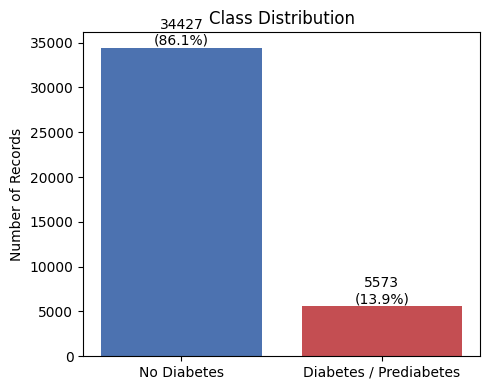

In [33]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = sample[TARGET_COL].value_counts().sort_index()
labels = ["No Diabetes", "Diabetes / Prediabetes"]
ax.bar(labels, counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of Records")
ax.set_title("Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}\n({v / counts.sum():.1%})", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_distribution.png", dpi=150)
plt.show()

## Correlation heatmap

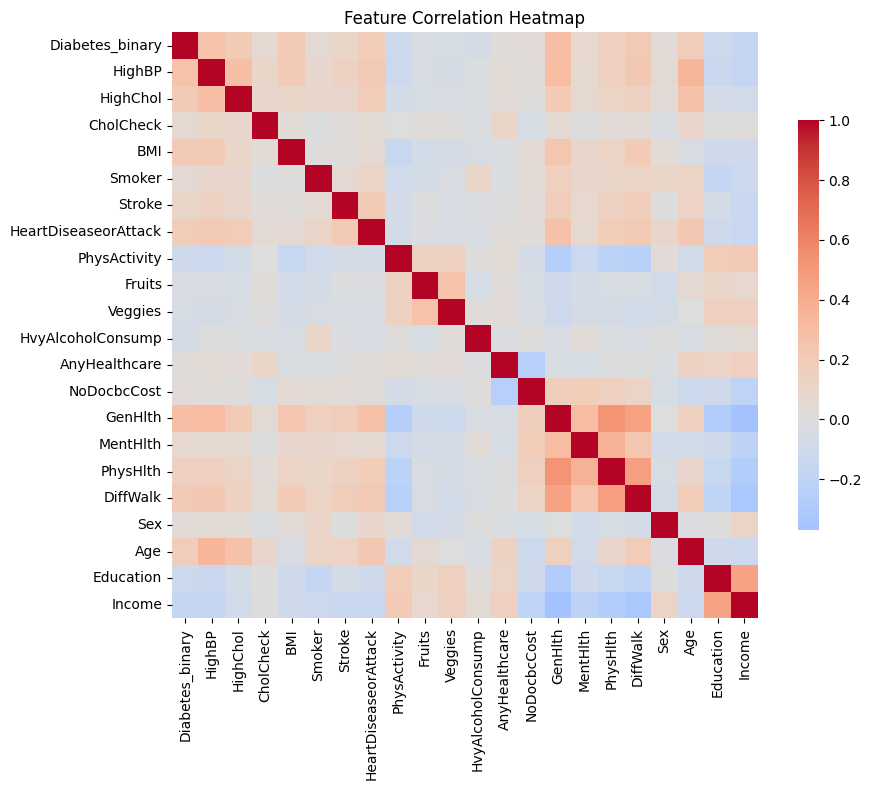

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = sample.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.7})
ax.set_title("Feature Correlation Heatmap")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

## Descriptive statistics (numeric columns)

In [35]:
stats = sample[NUMERIC_COLS].describe().T
stats.to_csv(DATA_DIR / "descriptive_stats.csv")
stats

,count,mean,std,min,25%,50%,75%,max
BMI,40000.0,28.393250,6.659716,12.0,24.0,27.0,31.0,98.0
MentHlth,40000.0,3.195025,7.418205,0.0,0.0,0.0,2.0,30.0
PhysHlth,40000.0,4.255850,8.719994,0.0,0.0,0.0,3.0,30.0


## Feature Dictionary

Definitions below are taken from the CDC BRFSS 2015 codebook (the survey this dataset is derived from), not guessed from the column names.

| Feature | Type / Encoding | Meaning |
|---|---|---|
| Diabetes_binary (target) | binary 0/1 | 0 = no diabetes, 1 = prediabetes or diabetes |
| HighBP | binary | Ever told has high blood pressure |
| HighChol | binary | Ever told has high blood cholesterol |
| CholCheck | binary | Cholesterol checked within the past 5 years (~95%+ are 1 — nearly constant) |
| BMI | continuous (kg/m²) | Body Mass Index |
| Smoker | binary | Smoked ≥100 cigarettes in entire life |
| Stroke | binary | Ever told had a stroke |
| HeartDiseaseorAttack | binary | History of coronary heart disease or myocardial infarction |
| PhysActivity | binary | Any physical activity in past 30 days outside of job |
| Fruits | binary | Consumes fruit ≥1 time/day |
| Veggies | binary | Consumes vegetables ≥1 time/day |
| HvyAlcoholConsump | binary | Heavy drinker (men >14 drinks/week, women >7/week) — heavily imbalanced (~95%+ are 0) |
| AnyHealthcare | binary | Has any health care coverage |
| NoDocbcCost | binary | Needed a doctor in past 12 months but couldn't afford it |
| GenHlth | ordinal 1–5 | Self-rated general health (1=excellent ... 5=poor) |
| MentHlth | continuous 0–30 | Days mental health was "not good" in past 30 days |
| PhysHlth | continuous 0–30 | Days physical health was "not good" in past 30 days |
| DiffWalk | binary | Serious difficulty walking or climbing stairs |
| Sex | binary | 0 = female, 1 = male |
| Age | ordinal 1–13 | 5-year bands: 1=18-24 ... 13=80+ |
| Education | ordinal 1–6 | 1 = never attended ... 6 = college graduate |
| Income | ordinal 1–8 | 1 = <$10k ... 8 = ≥$75k |

**Note:** several public analyses of this dataset flag `GenHlth` as carrying an unusually large share of the predictive signal on its own — worth keeping in mind when interpreting the correlation heatmap and feature importances later, since it behaves almost like a proxy for the target rather than an independent risk factor.

## Per-feature distributions

Grouping columns by type (binary / ordinal / continuous) so each gets an appropriate plot.

In [36]:
BINARY_COLS = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex",
]
ORDINAL_COLS = ["GenHlth", "Age", "Education", "Income"]
CONTINUOUS_COLS = ["BMI", "MentHlth", "PhysHlth"]

### Binary features — proportion of "yes" (1)

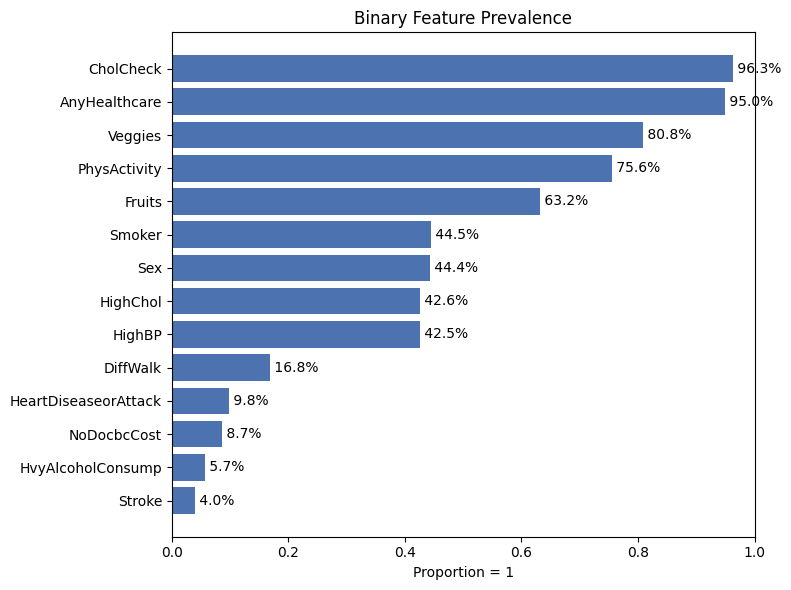

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
proportions = sample[BINARY_COLS].mean().sort_values()
ax.barh(proportions.index, proportions.values, color="#4C72B0")
ax.set_xlabel("Proportion = 1")
ax.set_title("Binary Feature Prevalence")
ax.set_xlim(0, 1)
for i, v in enumerate(proportions.values):
    ax.text(v, i, f" {v:.1%}", va="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "binary_feature_prevalence.png", dpi=150)
plt.show()

### Ordinal features — category counts

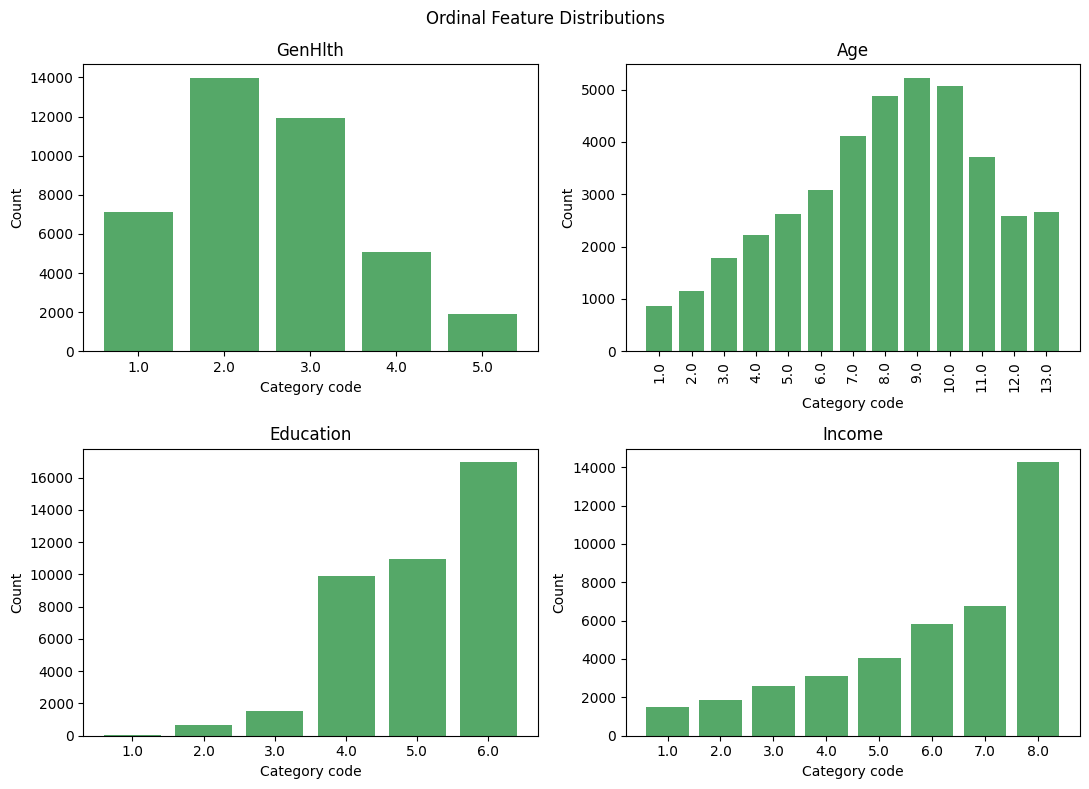

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, ORDINAL_COLS):
    counts = sample[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="#55A868")
    ax.set_title(col)
    ax.set_xlabel("Category code")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=90 if col in ("Age",) else 0)
fig.suptitle("Ordinal Feature Distributions")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "ordinal_feature_distributions.png", dpi=150)
plt.show()

### Continuous features — histograms

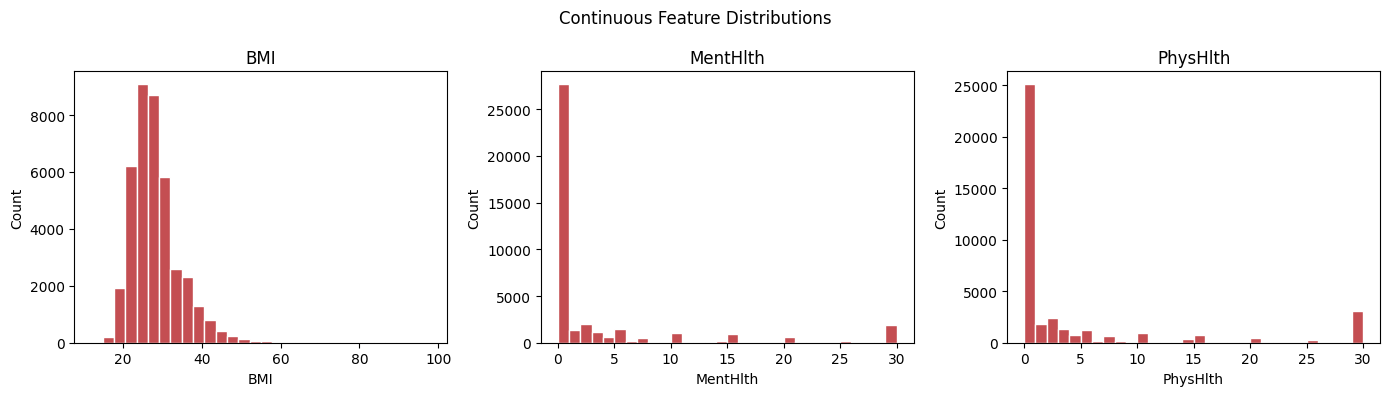

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CONTINUOUS_COLS):
    ax.hist(sample[col], bins=30, color="#C44E52", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
fig.suptitle("Continuous Feature Distributions")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "continuous_feature_distributions.png", dpi=150)
plt.show()

## Target relationship check

How each feature relates to `Diabetes_binary`: proportion/mean by class for binary and ordinal features, boxplots by class for continuous features.

In [40]:
by_target = sample.groupby(TARGET_COL)[BINARY_COLS + ORDINAL_COLS].mean().T
by_target.columns = ["No Diabetes", "Diabetes/Prediabetes"]
by_target["Difference"] = by_target["Diabetes/Prediabetes"] - by_target["No Diabetes"]
by_target.sort_values("Difference", ascending=False)

,No Diabetes,Diabetes/Prediabetes,Difference
Age,7.814332,9.373408,1.559076
GenHlth,2.392076,3.281895,0.889819
HighBP,0.372789,0.748609,0.375821
HighChol,0.385976,0.671631,0.285655
DiffWalk,0.135359,0.368204,0.232845
HeartDiseaseorAttack,0.074825,0.238471,0.163646
Smoker,0.433526,0.519469,0.085943
Stroke,0.032097,0.091872,0.059775
Sex,0.437244,0.484658,0.047414
CholCheck,0.957998,0.994437,0.036439


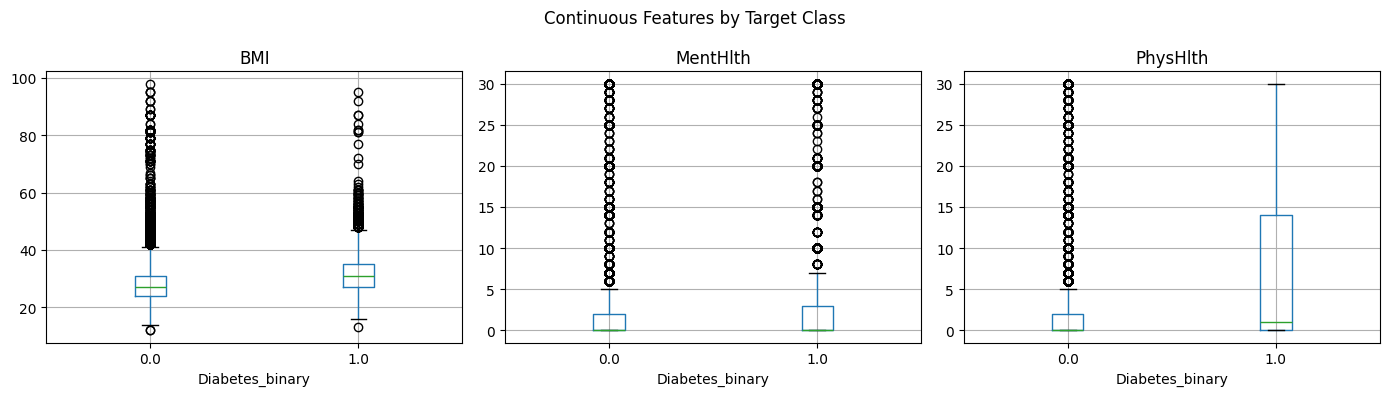

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, CONTINUOUS_COLS):
    sample.boxplot(column=col, by=TARGET_COL, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Diabetes_binary")
plt.suptitle("Continuous Features by Target Class")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "continuous_by_target.png", dpi=150)
plt.show()

**Observation:** `GenHlth` typically shows one of the largest gaps between classes in the table above (worse self-rated health strongly co-occurs with diabetes). Several public write-ups on this dataset flag this as a near-proxy relationship rather than a genuinely independent predictor — it reflects that people who already know they have health problems (including diabetes) tend to rate their general health worse, so its strength as a "predictor" partly reflects reverse causation. Worth discussing in the report rather than treating it as a straightforward causal risk factor.

## Save the stratified sample for downstream notebooks

In [42]:
sample.to_csv(DATA_DIR / "diabetes_sampled.csv", index=False)
print(f"Saved stratified sample to {DATA_DIR / 'diabetes_sampled.csv'}")

Saved stratified sample to C:\Users\ardao\Desktop\Projects\Bil476\data\diabetes_sampled.csv
